# A Quick Introduction to Large Language Models (LLMs)

Before we use AI tools to help us write code, it helps to know what is actually happening inside them. You do not need to know the exact libraries or functions beforehand, but you need a **mental model** good enough to predict when the tool will help and when it will mislead you.

```{admonition} Learning outcomes
:class: note

By the end, you should be able to:

- Explain what an LLM does and does not do, and how chat, inline completion, and agent tools differ.
- Write prompts that provide the context scientific code needs, including data structure, units, library versions, and constraints.
- Verify AI-generated analysis using sanity checks rather than trusting code simply because it runs.
- Identify common failure modes in climate and statistical code.
```

## What is an LLM?

A **Large Language Model (LLM)** is a neural network trained on a huge amount of text (books, websites, and a lot of public code) to do one thing:

> **Given some text, predict what comes next.**

ChatGPT, Claude, Gemini and GitHub Copilot are all built on LLMs. Most modern LLMs use the **Transformer** architecture, introduced by Google researchers in 2017 (*Attention Is All You Need*). Its key idea, *attention*, lets the model weigh how relevant every earlier piece of text is when predicting the next piece.

| Year | Milestone |
|------|-----------|
| 2017 | Transformer architecture published |
| Nov 2022 | ChatGPT (GPT-3.5) marks first LLM chatbot to reach a mass audience |
| 2023 onward | GPT-4, Claude, Gemini and others; rapid improvement in coding ability |

## Tokens: how an LLM reads text

An LLM does not see letters or words. A **tokenizer** first chops text into small pieces called **tokens**, then maps each token to an integer ID. The model only ever works with these numbers.

Let's look at a real tokenizer. `tiktoken` is OpenAI's open-source tokenizer library; other companies' models use different tokenizers, but they all work the same way.
You can also paste texts into the [OpenAI Tokenizer](https://platform.openai.com/tokenizer) web page instead. It highlights each token in a different colour and shows the token count.

In [ ]:
# Uncomment the next line if tiktoken is not installed
# !pip install -q tiktoken

import tiktoken

enc = tiktoken.get_encoding("o200k_base")  # the tokenizer used by GPT-4o-era OpenAI models


def show_tokens(text):
    ids = enc.encode(text)
    pieces = [enc.decode([i]) for i in ids]
    print(f"{text!r}  ->  {len(ids)} tokens")
    print("   pieces:", pieces)
    print("   IDs:   ", ids)
    print()

In [25]:
show_tokens("Daily rainfall at Changi")
show_tokens("evapotranspiration")
show_tokens("Rainfall on 12 Jan was 142.4 mm")
show_tokens("樟宜的日降雨量")  # "Daily rainfall at Changi" in Chinese

'Daily rainfall at Changi'  ->  5 tokens
   pieces: ['Daily', ' rainfall', ' at', ' Ch', 'angi']
   IDs:    [34217, 82809, 540, 1036, 23214]

'evapotranspiration'  ->  5 tokens
   pieces: ['ev', 'ap', 'otrans', 'p', 'iration']
   IDs:    [6923, 403, 169597, 79, 11960]

'Rainfall on 12 Jan was 142.4 mm'  ->  12 tokens
   pieces: ['Rain', 'fall', ' on', ' ', '12', ' Jan', ' was', ' ', '142', '.', '4', ' mm']
   IDs:    [74615, 14229, 402, 220, 899, 11558, 673, 220, 18330, 13, 19, 8957]

'樟宜的日降雨量'  ->  8 tokens
   pieces: ['�', '�', '宜', '的', '日', '降', '雨', '量']
   IDs:    [14491, 253, 67176, 1616, 2292, 36722, 53307, 13323]



Things to notice when you run the cell above:

- Common words are usually **one token**, often including the leading space (`" rainfall"`); rare or long words are split into pieces.
- Numbers such as `142.4` are split into fragments, not stored as a single value.
- Non-English text can sometimes uses **more tokens** per character.

A rough rule of thumb for English: **1 token ≈ ¾ of a word**, so 100 tokens ≈ 75 words. Let's check it on a paragraph:

In [26]:
paragraph = (
    "Singapore has a tropical rainforest climate with no distinct seasons. "
    "Rainfall is abundant throughout the year, but the northeast monsoon "
    "from December to early March brings some of the wettest weeks, "
    "with long spells of continuous rain."
)
n_words = len(paragraph.split())
n_tokens = len(enc.encode(paragraph))
print(f"{n_words} words, {n_tokens} tokens, {n_words / n_tokens:.2f} words per token")

37 words, 44 tokens, 0.84 words per token


```{note}
**Why this matters for coding:** an LLM processes `142.4` as tokens (text fragments), rather than as a numerical value in the way Python does. This can contribute to errors in numerical reasoning, such as confusing which decimal is larger ([9.9 or 9.11?][number-tokenization]). For calculations, let Python do the arithmetic rather than relying on the chatbot.

[number-tokenization]: https://huggingface.co/spaces/huggingface/number-tokenization-blog
```

## Predicting the next token

Text generation is a simple loop:

1. Read all the tokens so far.
2. Output a **probability for every possible next token**.
3. Pick one, append it, and repeat.

A long answer, or a whole Python script, is just this step repeated hundreds of times.

Below is a **toy** version. Suppose the prompt is *"The wettest month in Singapore is usually"*. The model produces a raw score (a *logit*) for each candidate token, and turns the scores into probabilities with the *softmax* function. The numbers here are made up for illustration.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [" November", " December", " January", " April", " July"]
logits = np.array([3.0, 2.4, 1.2, 0.6, -0.5])  # toy logits, not from a real LLM


def next_token_probs(logits, temperature=1.0):
    # Softmax with temperature: higher temperature -> flatter distribution
    z = logits / temperature
    z = z - z.max()  # for numerical stability
    p = np.exp(z)
    return p / p.sum()


probs = pd.Series(next_token_probs(logits), index=candidates).round(3)
probs

November    0.545
December    0.299
January     0.090
April       0.049
July        0.016
dtype: float64

Most chat tools do not always pick the most likely token. They **sample** from these probabilities, and a setting called **temperature** controls how adventurous the sampling is:

- **Low temperature** → almost always the top token (predictable, repetitive).
- **High temperature** → lower-probability tokens get picked more often (varied, sometimes wrong).

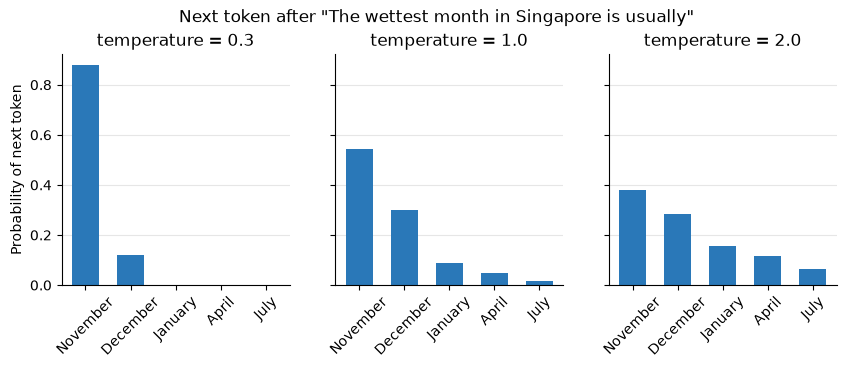

In [28]:
temperatures = [0.3, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, t in zip(axes, temperatures):
    p = next_token_probs(logits, t)
    ax.bar([c.strip() for c in candidates], p, color="#2a78b8", width=0.6)
    ax.set_title(f"temperature = {t}")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", color="0.9")
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("Probability of next token")
fig.suptitle('Next token after "The wettest month in Singapore is usually"', y=1.03)
plt.show()

In [45]:
rng = np.random.default_rng(0)

# Generate the next token 1,000 times at each temperature and count the results
for t in temperatures:
    p = next_token_probs(logits, t)
    picks = pd.Series(rng.choice(candidates, size=1000, p=p)).str.strip()
    counts = picks.value_counts().reindex([c.strip() for c in candidates], fill_value=0)
    print(f"T = {t}:", ", ".join(f"{k} {v}" for k, v in counts.items()))

T = 0.3: November 880, December 119, January 1, April 0, July 0
T = 1.0: November 568, December 279, January 87, April 50, July 16
T = 2.0: November 379, December 294, January 143, April 127, July 57


Three consequences follow directly:

- **It produces *plausible* text, not *verified* text.** The model has no built-in fact-checker. A wrong answer is generated in exactly the same way, and with the same confident tone, as a right one.
- **Answers vary between runs.** Because of sampling, asking the same question twice may give you different code.
- **Knowledge is frozen at training time.** The model learned from text up to its *training cutoff*. Libraries keep changing, so LLMs often suggest code that used to work. Two examples that break with current NumPy and pandas:

In [30]:
import warnings

print("NumPy", np.__version__, "| pandas", pd.__version__, "\n")

# 1. np.NaN was removed in NumPy 2.0
try:
    x = np.NaN
except AttributeError as err:
    print("np.NaN      ->", err)

# 2. Frequency alias "H" (hourly) was deprecated in pandas 2.2 and removed in pandas 3.0
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    try:
        pd.date_range("2021-01-01", periods=3, freq="H")
        print('freq="H"    -> still works, but warns:', caught[-1].message if caught else "no warning")
    except ValueError as err:
        print('freq="H"    ->', str(err).split(".")[0] + ". Use 'h' instead.")

# The modern versions
print("\nnp.nan =", np.nan)
print(pd.date_range("2021-01-01", periods=3, freq="h"))

NumPy 2.5.3 | pandas 3.0.6 

np.NaN      -> `np.NaN` was removed in the NumPy 2.0 release. Use `np.nan` instead.
freq="H"    -> Invalid frequency: H. Use 'h' instead.

np.nan = nan
DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 01:00:00',
               '2021-01-01 02:00:00'],
              dtype='datetime64[us]', freq='h')


## The context window: the model's working memory

Everything the model can "see" when answering is its **context**: the system instructions, your conversation so far, any files or data you pasted, and the answer it is currently writing.

- The context has a maximum size, the **context window**, measured in tokens. As of 2026, leading models accept from a few hundred thousand up to around a million tokens — but these numbers change every few months.
- **The model knows nothing about your data unless it is in the context.** It has never seen your CSV. If you do not tell it the column names, units or what a code value means, it will guess.
- Bigger is not always better: very long contexts can make the model lose track of details buried in the middle. Give it the relevant information, not everything.

Take the Changi daily rainfall data used in the Pandas tutorial. Is it a good idea to paste the whole file into a chat?

In [31]:
url = "https://raw.githubusercontent.com/XiaogangHe/python-climate-visuals/master/assets/data/Changi_daily_rainfall.csv"
df = pd.read_csv(url, index_col=0, header=0, parse_dates=True)

csv_text = df.to_csv()
print(f"{len(df):,} rows, {len(csv_text):,} characters")
print(f"Roughly {len(csv_text) // 4:,} tokens (using ~4 characters per token as a rough guide)")

14,610 rows, 236,239 characters
Roughly 59,059 tokens (using ~4 characters per token as a rough guide)


That is a lot of context spent on numbers the model does not need to see. A short **summary** of the data's structure is far more useful: it tells the model exactly what it needs to write correct code:

In [32]:
def describe_for_prompt(df, units=None):
    # Build a compact text description of a DataFrame to paste into an AI prompt
    lines = [
        f"DataFrame with {len(df):,} rows and {df.shape[1]} column(s).",
        f"Index: {type(df.index).__name__} from {df.index.min()} to {df.index.max()}"
        + (f" (frequency: {pd.infer_freq(df.index)})" if isinstance(df.index, pd.DatetimeIndex) else ""),
        "Columns:",
    ]
    for col in df.columns:
        unit = f", units: {units[col]}" if units and col in units else ""
        lines.append(f"  - {col!r}: dtype {df[col].dtype}, {df[col].isna().sum()} missing values{unit}")
    lines.append("First rows:")
    lines.append(df.head(3).to_string())
    return "\n".join(lines)


data_summary = describe_for_prompt(df, units={"Daily Rainfall Total (mm)": "mm/day"})
print(data_summary)

DataFrame with 14,610 rows and 1 column(s).
Index: DatetimeIndex from 1981-01-01 00:00:00 to 2020-12-31 00:00:00 (frequency: D)
Columns:
  - 'Daily Rainfall Total (mm)': dtype float64, 0 missing values, units: mm/day
First rows:
            Daily Rainfall Total (mm)
Date                                 
1981-01-01                        0.0
1981-01-02                        0.0
1981-01-03                        0.0


## Prompts: how you steer the model

A **prompt** is the text you give the model. As the model continues whatever it is given, a more specific prompt narrows down which continuations are likely.

- **System prompt** — background instructions set by the app or developer (e.g. *"You are a patient tutor; give hints, not full answers"*).
- **User prompt** — your actual request.

For scientific code, a good prompt covers five things:

| Part | Ask yourself | Example |
|------|--------------|---------|
| **Context** | What is this for? | "Describing the seasonal rainfall pattern at Changi for a course project" |
| **Data** | What exactly does it look like? | Paste the data summary, including units |
| **Task** | What should the output be? | "Mean monthly rainfall for each calendar month, as a bar chart" |
| **Constraints** | Which tools and versions? | "pandas ≥ 2.2, NumPy ≥ 2, matplotlib" |
| **Verification** | How will I know it is right? | "List 3 checks I should run on the result" |

❌ **Weak:** *"Write code to plot Changi rainfall."*

✅ **Strong:** built below from the data summary we just made.

In [33]:
strong_prompt = f'''I am describing the seasonal rainfall pattern at Changi, Singapore, for a course project.

My data is a pandas DataFrame called `df`:
{data_summary}

Task: for each calendar month (Jan-Dec), compute the mean monthly rainfall
total over all years in the data, and plot it as a bar chart.

Constraints: pandas >= 2.2 and NumPy >= 2 syntax; matplotlib for the plot.
Label the axes with units. Explain your approach in 2-3 sentences before
writing the code.

After the code, list 3 checks I should run to confirm the result is correct.'''

print(strong_prompt)

I am describing the seasonal rainfall pattern at Changi, Singapore, for a course project.

My data is a pandas DataFrame called `df`:
DataFrame with 14,610 rows and 1 column(s).
Index: DatetimeIndex from 1981-01-01 00:00:00 to 2020-12-31 00:00:00 (frequency: D)
Columns:
  - 'Daily Rainfall Total (mm)': dtype float64, 0 missing values, units: mm/day
First rows:
            Daily Rainfall Total (mm)
Date                                 
1981-01-01                        0.0
1981-01-02                        0.0
1981-01-03                        0.0

Task: for each calendar month (Jan-Dec), compute the mean monthly rainfall
total over all years in the data, and plot it as a bar chart.

Constraints: pandas >= 2.2 and NumPy >= 2 syntax; matplotlib for the plot.
Label the axes with units. Explain your approach in 2-3 sentences before
writing the code.

After the code, list 3 checks I should run to confirm the result is correct.


## From chatbot to agent

The same LLM can be used in different ways:

| Mode | What it does | Who runs the code? |
|------|--------------|--------------------|
| **Chat** (ChatGPT, Claude, Gemini) | You paste code or questions in, copy code out | **You** |
| **Inline completion** (e.g. Copilot in VS Code) | Suggests the next few lines as you type | **You** |
| **Agent** (e.g. Claude Code, Codex, Gemini CLI, Colab's Data Science Agent) | Given **tools** (read files, write code, run it), it works in a loop until the task is done | **The agent** |

An agent's loop looks like this:

```text
Goal → Plan → Act (edit / run code) → Observe (output or error) → repeat until done
```

```{important}
**Agents fix code that crashes, not code that runs but is wrong.**

A crash produces an error message, which the agent can read and act on. Code that runs but gives the wrong answer produces nothing, so the agent has no reason to look again. Spotting those mistakes takes domain knowledge, and that part is **YOUR** job. We'll see this in the live demo in the next section.
```

## Live demo: plausible but wrong

We have seen *why* LLMs can produce confident, wrong answers. Now let's watch it happen. We give an AI agent a request of the kind you would genuinely get from a stakeholder (which most of the time, is an underspecified one) and look closely at what comes back.

**The data.** One year (2025) of synthetic daily rainfall from 12 rain gauges (`S01`–`S12`) across Singapore, in `rain_gauges_2025.csv`.

```{note}
The dataset is **synthetic**. We generated it, so we know the true answer. The data-quality problems in it are the kind that appear in real monitoring networks.
```

### The request

> *"Here's a year of daily rainfall from our 12 rain gauges. Which areas got the most rain in 2025? Give me the top 5, and we'll prioritise them for drain upgrades."*

We pass this, together with the CSV, to an AI coding agent.

**Before we run it, let's poll: what do you expect to go wrong?**

1. It will crash / write code that doesn't run
2. It will run, and the answer will be right
3. It will run, and the answer will be wrong in a way I can see
4. It will run, and the answer will be wrong in a way I can't see

### What the agent gave us

Reasonable-looking code. It runs cleanly, with no warnings.

In [ ]:
import pandas as pd

df = pd.read_csv("../../assets/data/llm_rain_gauges_2025.csv", parse_dates=["date"])

# Total rainfall per station in 2025
totals = (
    df.groupby(["station", "region"])["rainfall_mm"]
      .sum()
      .sort_values(ascending=False)
)
top5_agent = totals.head(5)
top5_agent

station  region 
S07      West       42502.0
S10      Central     2861.5
S05      East        2679.7
S08      West        2501.9
S01      North       2360.4
Name: rainfall_mm, dtype: float64

Is that an answer you would send to your stakeholder?

### Bug #1 — the one you can see

Singapore typically gets a couple of thousand millimetres of rain a year. Station `S07` reports over **40,000 mm**. Let's look at the values themselves:

In [35]:
df["rainfall_mm"].describe()

count    4392.000000
mean       15.423679
std       301.763889
min         0.000000
25%         0.000000
50%         0.000000
75%         6.900000
max      9999.000000
Name: rainfall_mm, dtype: float64

In [36]:
df[df["rainfall_mm"] > 1000]

,date,station,region,rainfall_mm
172,2025-06-02,S07,West,9999.0
344,2025-09-21,S07,West,9999.0
1460,2025-03-14,S07,West,9999.0
1805,2025-06-03,S07,West,9999.0


Four days of exactly **9999 mm**. That is not rainfall data, but an error code. The gauge's **data dictionary**, which nobody gave the agent, will say so at another place:

| Column | Meaning |
|---|---|
| `date` | Calendar date (local time) |
| `station` | Gauge ID |
| `region` | Area of Singapore |
| `rainfall_mm` | Daily rainfall total in mm. **`9999` = sensor fault, value unknown.** Dates with no record = logger offline. |

The agent was never told this, so it summed the error codes as if they were rain. Let's treat them as missing and try again.

In [37]:
import numpy as np

df_clean = df.copy()
df_clean["rainfall_mm"] = df_clean["rainfall_mm"].replace(9999, np.nan)

totals_fixed = (
    df_clean.groupby(["station", "region"])["rainfall_mm"]
            .sum()
            .sort_values(ascending=False)
)
top5_fixed = totals_fixed.head(5)
top5_fixed

station  region 
S10      Central    2861.5
S05      East       2679.7
S07      West       2506.0
S08      West       2501.9
S01      North      2360.4
Name: rainfall_mm, dtype: float64

Plausible. Defensible. Around 2,400–2,900 mm, which is about what you'd expect for a year in Singapore.

So we're done, right?

### Bug #2 (and #3) — the ones you can't see

Every station should have exactly **365 rows**, one per day. That is a one-line check:

In [38]:
df_clean.groupby("station").size()

station
S01    365
S02    365
S03    318
S04    365
S05    365
S06    365
S07    365
S08    365
S09    365
S10    424
S11    365
S12    365
dtype: int64

Two stations are wrong, in opposite directions:

- **`S03` has 318 rows** — 47 days are missing.
- **`S10` has 424 rows** — 59 days appear twice.

In [39]:
# Which dates are missing at S03?
all_days = pd.date_range("2025-01-01", "2025-12-31", freq="D")
s03_days = df_clean.loc[df_clean["station"] == "S03", "date"]
missing = all_days.difference(s03_days)
print(f"S03 is missing {len(missing)} days: {missing.min().date()} to {missing.max().date()}")

# Which rows are duplicated at S10?
dups = df_clean[df_clean.duplicated(subset=["station", "date"], keep="first")]
print(f"{len(dups)} duplicated rows, all at {', '.join(dups['station'].unique())}, "
      f"from {dups['date'].min().date()} to {dups['date'].max().date()}")

S03 is missing 47 days: 2025-11-15 to 2025-12-31
59 duplicated rows, all at S10, from 2025-01-01 to 2025-02-28


- `S03`'s logger went **offline from 15 November** to the end of the year. Those days are **not** `NaN`. They are simply absent, so `.sum()` has nothing to warn about. `S03` looks drier than it was.
- `S10`'s logger **re-uploaded January and February**, so those days are counted twice. `S10` looks wetter than it was, enough to reach the top of the list.

Nothing crashed. Nothing warned.

#### A tempting fix that is still wrong

"Just scale `S03` up to a full year" sounds reasonable. But look *when* the gap happened:

In [40]:
deduped = df_clean.drop_duplicates(subset=["station", "date"])
monthly = deduped.groupby(deduped["date"].dt.month)["rainfall_mm"].mean().round(1)
monthly.index.name = "month"
monthly.rename("mean daily rainfall (mm), all stations")

month
1     14.1
2      7.8
3      3.4
4      4.1
5      4.2
6      3.7
7      5.1
8      4.9
9      4.8
10     6.4
11     7.3
12     9.7
Name: mean daily rainfall (mm), all stations, dtype: float64

The missing weeks fall in the **wettest part of the year** (the northeast monsoon). Scaling up by the number of days would assume `S03` missed an *average* seven weeks of weather, and would still underestimate it.

#### The comparison the stakeholder actually wanted

"Which areas got the most rain" is a comparison **between places**. A fair comparison uses the **same days for every station**:

1. Remove the duplicated rows.
2. Treat `9999` as missing.
3. Keep only the days on which **every** station has a valid reading, then compare mean daily rainfall.

In [41]:
# One column per station; keep only days where all 12 stations have a valid value
wide = deduped.pivot(index="date", columns="station", values="rainfall_mm")
common = wide.dropna()
print(f"{len(common)} of 365 days have valid data at every station")

corrected = common.mean().sort_values(ascending=False).round(2)
corrected.name = "mean daily rainfall on common days (mm)"
corrected.head(5)

314 of 365 days have valid data at every station


station
S03    7.50
S05    6.88
S07    6.62
S08    6.53
S01    6.12
Name: mean daily rainfall on common days (mm), dtype: float64

In [42]:
agent_top5 = list(top5_agent.index.get_level_values("station"))
fixed_top5 = list(top5_fixed.index.get_level_values("station"))
correct_top5 = list(corrected.index[:5])

pd.DataFrame(
    {"agent": agent_top5, "after fixing 9999": fixed_top5, "corrected": correct_top5},
    index=pd.RangeIndex(1, 6, name="rank"),
)

,agent,after fixing 9999,corrected
rank,,,
1,S07,S10,S03
2,S10,S05,S05
3,S05,S07,S07
4,S08,S08,S08
5,S01,S01,S01


The **wettest station (`S03`) was missing from both earlier lists**, and `S10`, which should not be in the top 5 at all, was ranked **#1** after the "obvious" fix.

Because the data is synthetic, we can check against the truth (the clean data before any problems were introduced):

In [ ]:
truth = pd.read_csv("../../assets/data/llm_rain_gauges_2025_truth.csv", parse_dates=["date"])
true_totals = truth.groupby("station")["rainfall_mm"].sum().sort_values(ascending=False)

print("true top 5:     ", list(true_totals.index[:5]))
print("corrected top 5:", correct_top5)
print("agent's top 5:  ", agent_top5)

true top 5:      ['S03', 'S05', 'S07', 'S08', 'S01']
corrected top 5: ['S03', 'S05', 'S07', 'S08', 'S01']
agent's top 5:   ['S07', 'S10', 'S05', 'S08', 'S01']


### The point

- The agent's first answer contained an **obvious** error (9999 mm). Fixing it produced numbers that looked **completely reasonable**, and made us *more* confident in a list that was still wrong.
- The remaining problems (a logger outage and a duplicate upload) produce **no error, no warning and no strange values**. They were only visible through a boring check: *does each station have 365 rows?*
- The final answer comes with a caveat worth telling the stakeholder: `S03`'s total for 2025 cannot be stated exactly, because about seven of its wettest weeks were never recorded.

#### None of this is the agent's fault, exactly

It was asked a vague question, and it answered it. It had no data dictionary, and nobody told it what the numbers meant.

| What went wrong | Where this notebook addresses it |
|---|---|
| "Most rain" was never defined; no one asked for a fair comparison | **Prompts (Section 5)** — ask the question you actually mean |
| `9999` means "sensor fault" | **Context (Section 4)** — the model only knows what you put in its context |
| How would I have caught the gap and the duplicates? | **Verification** — the sanity check below |

A better prompt would have included the data dictionary and one extra line:

> *"Before answering, check the data for error codes, missing dates and duplicate rows, and tell me what you found."*

### A reusable check

The checks we just did by hand take a few lines, and they can be modified and applied to other time-series dataset:

In [44]:
def check_daily_data(df, id_col, date_col, value_col, flags=(9999,)):
    # Quick data-quality report for a long-format daily dataset
    days = pd.date_range(df[date_col].min(), df[date_col].max(), freq="D")
    report = pd.DataFrame({
        "rows": df.groupby(id_col).size(),
        "expected": len(days),
        "duplicates": df[df.duplicated([id_col, date_col])].groupby(id_col).size(),
        "flagged": df[df[value_col].isin(flags)].groupby(id_col).size(),
        "NaN": df[value_col].isna().groupby(df[id_col]).sum(),
        "min": df[~df[value_col].isin(flags)].groupby(id_col)[value_col].min(),
        "max": df[~df[value_col].isin(flags)].groupby(id_col)[value_col].max(),
    }).fillna(0)
    report["missing_days"] = report["expected"] - (report["rows"] - report["duplicates"])
    problems = (report["missing_days"] > 0) | (report["duplicates"] > 0) | (report["flagged"] > 0)
    return report.astype({"duplicates": int, "flagged": int, "NaN": int, "missing_days": int})[problems]


check_daily_data(df, "station", "date", "rainfall_mm")

,rows,expected,duplicates,flagged,NaN,min,max,missing_days
station,,,,,,,,
S03,318,365,0,0,0,0.0,131.7,47
S07,365,365,0,4,0,0.0,104.9,0
S10,424,365,59,0,0,0.0,101.1,0


Three stations, three different problems, one table. Run a check like this **before** you ask any question of a new dataset. Regardless whether you wrote the analysis or an AI did.

## Key takeaways

1. An LLM **predicts the next token**. It generates plausible text, not verified truth.
2. It reads **tokens**, not numbers. Let Python do the maths.
3. It only knows what is in its **context**. Tell it about your data, units and library versions.
4. Its knowledge has a **cutoff**. Expect outdated syntax.
5. Output **varies between runs**. Never assume one run is representative.
6. **Code that runs is not code that is correct.** Always check units, row counts, missing and duplicated values, and whether the numbers are physically plausible.
7. You must be able to **explain every line you submit**, and cite your AI use according to the course policy.

## Try it yourself

1. Use `show_tokens()` on your own name, once in English and once in another language you know. Which uses more tokens?
2. Re-run the sampling cell with `temperature = 0.05` and `temperature = 5`. What happens, and which setting would you want for writing code?